In [60]:
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.models import resnet18
from torchvision.transforms import Compose, Normalize, ToTensor, Compose

from ignite.engine import Engine, Events, create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss, Precision, Recall
from ignite.handlers import ModelCheckpoint
from ignite.contrib.handlers import TensorboardLogger, global_step_from_engine

import medmnist
from medmnist import INFO, Evaluator

import numpy as np

import os
import shutil

from tqdm import tqdm

# set seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True

# delete existing checkpoint and logger files in current directory
shutil.rmtree('checkpoint', ignore_errors=True)
shutil.rmtree('tb-logger', ignore_errors=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [61]:
data_flag = 'pneumoniamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [62]:
# define resnet18 model and adapt to greyscale dataset

class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        
        # Changed the output layer to output 2 classes instead of 1000 classes
        self.model = resnet18(num_classes=n_classes)

        # Changed the input layer to take grayscale images for MNIST instead of RGB images
        self.model.conv1 = nn.Conv2d(
            1, 64, kernel_size=3, padding=1, bias=False
        )

    def forward(self, x):
        return self.model(x)


model = Net().to(device)

# define data transform and loaders

data_transform = Compose([
    ToTensor(),
    Normalize(mean=[.5], std=[.5])
])

root = "./"
log_interval = 100

In [63]:
def ignite_train_loop(model, optimizer_name, batch_size, lr, weight_decay, device):

    train_dataset = DataClass(root=root, split='train', transform=data_transform, download=download)
    val_dataset = DataClass(root=root, split='val', transform=data_transform, download=download)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=2*batch_size, shuffle=False)

    test_dataset = DataClass(root=root, split='test', transform=data_transform, download=download)
    test_loader = DataLoader(test_dataset, batch_size=2*batch_size, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    optimizer = getattr(optim, optimizer_name)(model.parameters(), lr=lr, weight_decay=weight_decay)

    trainer = create_supervised_trainer(model, optimizer, criterion, device)

    val_metrics = {
        "acc": Accuracy(),
        "loss": Loss(criterion)
    }

    test_metrics = {
        "acc": Accuracy(),
        "avg_precision": Precision(average=True),
        "avg_recall": Recall(average=True)
    }

    train_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)
    val_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)
    test_evaluator = create_supervised_evaluator(model, metrics=test_metrics, device=device)

    def train_step(engine, batch):
        model.train()
        
        optimizer.zero_grad()
        
        x, y = batch[0].to(device), batch[1].to(device)
        y_pred = model(x)
        y = y.squeeze().long()
        loss = criterion(y_pred, y)
        
        loss.backward()
        optimizer.step()
        
        return loss.item()

    trainer = Engine(train_step)

    def validation_step(engine, batch):
        model.eval()
        
        with torch.no_grad():
            x, y = batch[0].to(device), batch[1].to(device)
            y_pred = model(x)
            y = y.squeeze().long()
            return y_pred, y

    train_evaluator = Engine(validation_step)
    val_evaluator = Engine(validation_step)
    test_evaluator = Engine(validation_step)

    # Attach metrics to the evaluators
    for name, metric in val_metrics.items():
        metric.attach(train_evaluator, name)

    for name, metric in val_metrics.items():
        metric.attach(val_evaluator, name)

    for name, metric in test_metrics.items():
        metric.attach(test_evaluator, name)

    @trainer.on(Events.STARTED)
    def log_training_start(engine):
        print("Training started")

    @trainer.on(Events.ITERATION_COMPLETED(every=log_interval))
    def log_training_loss(engine):
        print(f"Epoch[{engine.state.epoch}], Iter[{engine.state.iteration}] Loss: {engine.state.output:.2f}")

    @trainer.on(Events.EPOCH_COMPLETED)
    def log_training_results(trainer):
        train_evaluator.run(train_loader)
        metrics = train_evaluator.state.metrics
        print(f"Training Results - Epoch[{trainer.state.epoch}] Avg accuracy: {metrics['acc']:.2f} Avg loss: {metrics['loss']:.2f}")

    @trainer.on(Events.EPOCH_COMPLETED)
    def log_validation_results(trainer):
        val_evaluator.run(val_loader)
        metrics = val_evaluator.state.metrics
        print(f"Validation Results - Epoch[{trainer.state.epoch}] Avg accuracy: {metrics['acc']:.2f} Avg loss: {metrics['loss']:.2f}")

    @trainer.on(Events.COMPLETED)
    def log_test_results(engine):
        # delete existing checkpoint and logger files in current directory for next run
        shutil.rmtree('checkpoint', ignore_errors=True)
        shutil.rmtree('tb-logger', ignore_errors=True)
        test_evaluator.run(test_loader)
        metrics = test_evaluator.state.metrics
        #print(metrics)
        print("--- EVAL ON TEST SET ---")
        print(f"Test Results - Avg accuracy: {metrics['acc']:.2f} "
            f"Avg precision: {metrics['avg_precision']:.2f} "
            f"Avg recall: {metrics['avg_recall']:.2f} "
            )
        return metrics['acc']
        

    def score_function(engine):
        return engine.state.metrics["acc"]

    model_checkpoint = ModelCheckpoint(
        "checkpoint",
        n_saved=2,
        filename_prefix="best",
        score_function=score_function,
        score_name="acc",
        global_step_transform=global_step_from_engine(trainer),
    )

    
    val_evaluator.add_event_handler(Events.COMPLETED, model_checkpoint, {"model": model})

    tb_logger = TensorboardLogger(log_dir="tb-logger")

    tb_logger.attach_output_handler(
        trainer,
        event_name=Events.ITERATION_COMPLETED(every=100),
        tag="training",
        output_transform=lambda loss: {"batch_loss": loss},
    )

    for tag, evaluator in [("training", train_evaluator), ("validation", val_evaluator)]:
        tb_logger.attach_output_handler(
            evaluator,
            event_name=Events.EPOCH_COMPLETED,
            tag=tag,
            metric_names="all",
            global_step_transform=global_step_from_engine(trainer),
        )

    trainer.run(train_loader, max_epochs=5)
    tb_logger.close()


ignite_train_loop(model, 'Adam', 64, 0.001, 0.0001, device)

Using downloaded and verified file: ./pneumoniamnist.npz
Using downloaded and verified file: ./pneumoniamnist.npz
Using downloaded and verified file: ./pneumoniamnist.npz
Training started
Training Results - Epoch[1] Avg accuracy: 0.98 Avg loss: 0.07
Validation Results - Epoch[1] Avg accuracy: 0.98 Avg loss: 0.07
Epoch[2], Iter[100] Loss: 0.38
Training Results - Epoch[2] Avg accuracy: 0.98 Avg loss: 0.06
Validation Results - Epoch[2] Avg accuracy: 0.97 Avg loss: 0.08
Epoch[3], Iter[200] Loss: 0.13
Training Results - Epoch[3] Avg accuracy: 0.98 Avg loss: 0.04
Validation Results - Epoch[3] Avg accuracy: 0.97 Avg loss: 0.09
Training Results - Epoch[4] Avg accuracy: 0.99 Avg loss: 0.03
Validation Results - Epoch[4] Avg accuracy: 0.97 Avg loss: 0.07
Epoch[5], Iter[300] Loss: 0.06
Training Results - Epoch[5] Avg accuracy: 0.99 Avg loss: 0.02
Validation Results - Epoch[5] Avg accuracy: 0.97 Avg loss: 0.09
--- EVAL ON TEST SET ---
Test Results - Avg accuracy: 0.85 Avg precision: 0.88 Avg recall

In [64]:
!pip install optuna optuna-integration


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
from ignite.engine import create_supervised_evaluator
from ignite.engine import create_supervised_trainer
from ignite.engine import Events, Engine
from ignite.metrics import Accuracy
import optuna
import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader
from torch.utils.data import Subset
from torchvision.datasets.mnist import FashionMNIST
from torchvision.transforms import Compose
from torchvision.transforms import Normalize
from torchvision.transforms import ToTensor

EPOCHS = 10
TRAIN_BATCH_SIZE = 128
VAL_BATCH_SIZE = 256
N_TRAIN_EXAMPLES = 30 * VAL_BATCH_SIZE
N_VALID_EXAMPLES = 10 * VAL_BATCH_SIZE

class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        
        # Changed the output layer to output 2 classes instead of 1000 classes
        self.model = resnet18(num_classes=n_classes)

        # Changed the input layer to take grayscale images for MNIST instead of RGB images
        self.model.conv1 = nn.Conv2d(
            1, 64, kernel_size=3, padding=1, bias=False
        )

    def forward(self, x):
        return self.model(x)


def get_data_loaders(train_batch_size, val_batch_size):
    data_transform = Compose([
    ToTensor(),
    Normalize(mean=[.5], std=[.5])
    ])

    train_dataset = DataClass(root=root, split='train', transform=data_transform, download=download)
    val_dataset = DataClass(root=root, split='val', transform=data_transform, download=download)

    train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=val_batch_size, shuffle=False)

    return train_loader, val_loader


def objective(trial):
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    model = Net().to(device)

    weight_decay = trial.suggest_float("weight_decay", 1e-10, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    optimizer = getattr(optim, optimizer_name)(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    
    val_metrics = {
        "accuracy": Accuracy(),
        "loss": Loss(criterion)
        }
    
    trainer = create_supervised_trainer(model, optimizer, criterion, device=device)
    evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)
    
    def train_step(engine, batch):
        model.train()
        
        optimizer.zero_grad()
        
        x, y = batch[0].to(device), batch[1].to(device)
        y_pred = model(x)
        y = y.squeeze().long()
        loss = criterion(y_pred, y)
        
        loss.backward()
        optimizer.step()
        
        return loss.item()

    trainer = Engine(train_step)

    def validation_step(engine, batch):
        model.eval()
        
        with torch.no_grad():
            x, y = batch[0].to(device), batch[1].to(device)
            y_pred = model(x)
            y = y.squeeze().long()
            return y_pred, y

    evaluator = Engine(validation_step)

    for name, metric in val_metrics.items():
        metric.attach(evaluator, name)

    # Register a pruning handler to the evaluator.
    pruning_handler = optuna.integration.PyTorchIgnitePruningHandler(trial, "accuracy", trainer)
    evaluator.add_event_handler(Events.COMPLETED, pruning_handler)

    # Load data
    train_loader, val_loader = get_data_loaders(TRAIN_BATCH_SIZE, VAL_BATCH_SIZE)

    @trainer.on(Events.EPOCH_COMPLETED)
    def log_results(engine):
        evaluator.run(val_loader)
        validation_acc = evaluator.state.metrics["accuracy"]
        print("Epoch: {} Validation accuracy: {:.2f}".format(engine.state.epoch, validation_acc))

    trainer.run(train_loader, max_epochs=EPOCHS)

    if trial.should_prune():
        raise optuna.TrialPruned()

    return evaluator.state.metrics["accuracy"]

sampler = optuna.samplers.TPESampler(seed=10)

pruner = optuna.pruners.MedianPruner()

n_trials = 100

study = optuna.create_study(direction="maximize", pruner=pruner, sampler=sampler)
study.optimize(objective, n_trials=n_trials, timeout=600)

print("Number of finished trials: ", len(study.trials))

print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2024-08-08 13:05:18,419] A new study created in memory with name: no-name-b0819c21-14dd-4910-87e7-7dc19bce041c


Using downloaded and verified file: ./pneumoniamnist.npz
Using downloaded and verified file: ./pneumoniamnist.npz
Epoch: 1 Validation accuracy: 0.75
Epoch: 2 Validation accuracy: 0.95
Epoch: 3 Validation accuracy: 0.96
Epoch: 4 Validation accuracy: 0.96
Epoch: 5 Validation accuracy: 0.96
Epoch: 6 Validation accuracy: 0.96
Epoch: 7 Validation accuracy: 0.97
Epoch: 8 Validation accuracy: 0.96
Epoch: 9 Validation accuracy: 0.97


[I 2024-08-08 13:05:26,973] Trial 0 finished with value: 0.9656488549618321 and parameters: {'weight_decay': 2.507520561353437e-05, 'optimizer': 'SGD', 'lr': 0.009890438121030055}. Best is trial 0 with value: 0.9656488549618321.


Epoch: 10 Validation accuracy: 0.97
Using downloaded and verified file: ./pneumoniamnist.npz
Using downloaded and verified file: ./pneumoniamnist.npz
Epoch: 1 Validation accuracy: 0.78
Epoch: 2 Validation accuracy: 0.96
Epoch: 3 Validation accuracy: 0.95
Epoch: 4 Validation accuracy: 0.96
Epoch: 5 Validation accuracy: 0.96
Epoch: 6 Validation accuracy: 0.92
Epoch: 7 Validation accuracy: 0.92
Epoch: 8 Validation accuracy: 0.95
Epoch: 9 Validation accuracy: 0.96


[I 2024-08-08 13:05:35,607] Trial 1 finished with value: 0.9446564885496184 and parameters: {'weight_decay': 3.087088544037578e-07, 'optimizer': 'Adam', 'lr': 0.011018509458263562}. Best is trial 0 with value: 0.9656488549618321.


...

Epoch: 10 Validation accuracy: 0.97
Using downloaded and verified file: ./pneumoniamnist.npz
Using downloaded and verified file: ./pneumoniamnist.npz


Engine run is terminating due to exception: Trial was pruned at 1 epoch.
Engine run is terminating due to exception: Trial was pruned at 1 epoch.
[I 2024-08-08 13:09:17,569] Trial 98 pruned. Trial was pruned at 1 epoch.


Using downloaded and verified file: ./pneumoniamnist.npz
Using downloaded and verified file: ./pneumoniamnist.npz


Engine run is terminating due to exception: Trial was pruned at 1 epoch.
Engine run is terminating due to exception: Trial was pruned at 1 epoch.
[I 2024-08-08 13:09:18,540] Trial 99 pruned. Trial was pruned at 1 epoch.


Number of finished trials:  100
Best trial:
  Value:  0.9751908396946565
  Params: 
    weight_decay: 1.9023434006546776e-06
    optimizer: SGD
    lr: 0.042564562178057576


In [66]:
# retrain model with best hyperparameters
best_params = trial.params

model = Net().to(device)

ignite_train_loop(model, best_params['optimizer'], 128, best_params['lr'], best_params['weight_decay'], device)

Using downloaded and verified file: ./pneumoniamnist.npz
Using downloaded and verified file: ./pneumoniamnist.npz
Using downloaded and verified file: ./pneumoniamnist.npz
Training started
Training Results - Epoch[1] Avg accuracy: 0.77 Avg loss: 0.74
Validation Results - Epoch[1] Avg accuracy: 0.76 Avg loss: 0.75
Training Results - Epoch[2] Avg accuracy: 0.99 Avg loss: 0.03
Validation Results - Epoch[2] Avg accuracy: 0.96 Avg loss: 0.10
Epoch[3], Iter[100] Loss: 0.01
Training Results - Epoch[3] Avg accuracy: 1.00 Avg loss: 0.01
Validation Results - Epoch[3] Avg accuracy: 0.97 Avg loss: 0.08
Training Results - Epoch[4] Avg accuracy: 1.00 Avg loss: 0.00
Validation Results - Epoch[4] Avg accuracy: 0.97 Avg loss: 0.09
Training Results - Epoch[5] Avg accuracy: 1.00 Avg loss: 0.00
Validation Results - Epoch[5] Avg accuracy: 0.98 Avg loss: 0.08
--- EVAL ON TEST SET ---
Test Results - Avg accuracy: 0.85 Avg precision: 0.89 Avg recall: 0.81 


In [67]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [68]:
# calculate AUPR, PRECISION, RECALL, F1 SCORE

from sklearn.metrics import precision_recall_curve, auc, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

test_dataset = DataClass(root=root, split='test', transform=data_transform, download=download)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


def calculate_metrics(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            y_pred.append(model(x).cpu().numpy())
            y_true.append(y.cpu().numpy())
    y_pred = np.vstack(y_pred)
    y_true = np.hstack(y_true)
    return y_true, y_pred

y_true, y_pred = calculate_metrics(model, test_loader)


acc = accuracy_score(y_true, y_pred.argmax(axis=1))
areaundercurve = roc_auc_score(y_true, y_pred[:, 1])
precision, recall, thresholds = precision_recall_curve(y_true, y_pred[:, 1])
aupr = auc(recall, precision)
precision = precision_score(y_true, y_pred.argmax(axis=1))
recall = recall_score(y_true, y_pred.argmax(axis=1))
f1 = f1_score(y_true, y_pred.argmax(axis=1))

print(f"Accuracy: {acc:.2f}")
print(f"AUC: {areaundercurve:.2f}")
print(f"AUPR: {aupr:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Using downloaded and verified file: ./pneumoniamnist.npz
Accuracy: 0.85
AUC: 0.96
AUPR: 0.96
Precision: 0.82
Recall: 0.99
F1 Score: 0.89


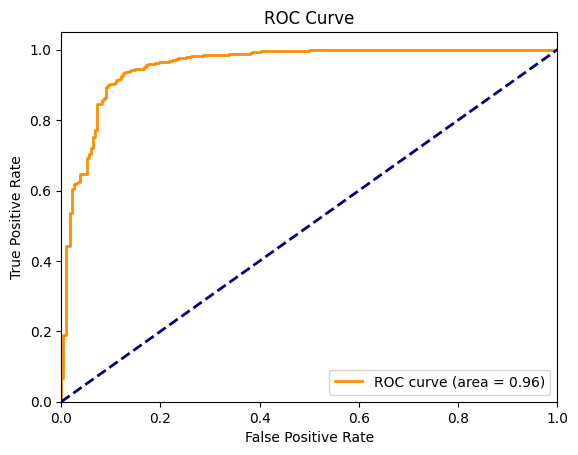

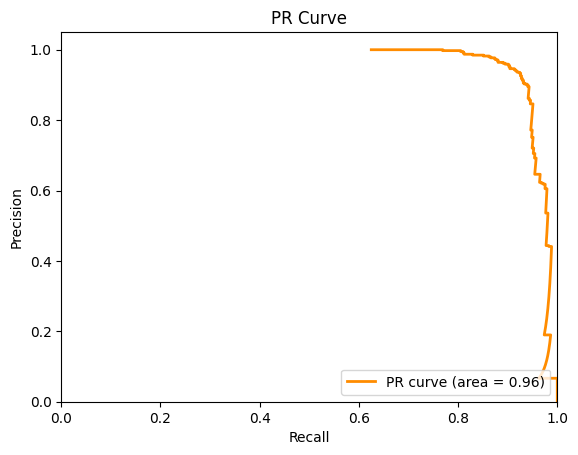

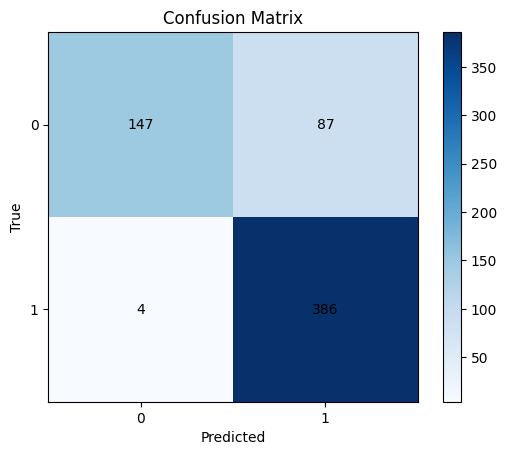

In [69]:
# plot ROC curve, PR curve, confusion matrix

from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_pred[:, 1])
roc_auc = roc_auc_score(y_true, y_pred[:, 1])

recall, precision, thresholds = precision_recall_curve(y_true, y_pred[:, 1])
#recall = np.append(0, recall)
#precision = np.append(1, precision)

# ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# PR curve
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (area = {aupr:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve')
plt.legend(loc="lower right")
plt.show()

# confusion matrix
cm = confusion_matrix(y_true, y_pred.argmax(axis=1))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.show()

In [71]:
# implementation of 5-fold cross validation

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, SubsetRandomSampler, ConcatDataset
from torchvision.datasets import MNIST
from torchvision.models import resnet18
from torchvision.transforms import Compose, Normalize, ToTensor

from sklearn.model_selection import KFold
import numpy as np

from ignite.engine import Events, create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss, RunningAverage

train_dataset = DataClass(root=root, split='train', transform=data_transform, download=download)

def initialize():
    model = Net().to(device)
    optimizer = getattr(optim, best_params['optimizer'])(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
    
    criterion = nn.CrossEntropyLoss()

    return model, optimizer, criterion

def setup_dataflow(dataset, train_idx, val_idx):
    train_sampler = SubsetRandomSampler(train_idx)
    val_sampler = SubsetRandomSampler(val_idx)

    train_loader = DataLoader(dataset, batch_size=128, sampler=train_sampler)
    val_loader = DataLoader(dataset, batch_size=256, sampler=val_sampler)

    return train_loader, val_loader

def train_model(train_loader, val_loader):
    max_epochs = 3

    train_results = []
    val_results = []

    model, optimizer, criterion = initialize()

    val_metrics = {
        "accuracy": Accuracy(),
        "loss": Loss(criterion)
        }

    trainer = create_supervised_trainer(model, optimizer, criterion, device=device)
    evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)

    def train_step(engine, batch):
        model.train()
        
        optimizer.zero_grad()
        
        x, y = batch[0].to(device), batch[1].to(device)
        y_pred = model(x)
        y = y.squeeze().long()
        loss = criterion(y_pred, y)
        
        loss.backward()
        optimizer.step()
        
        return loss.item()

    trainer = Engine(train_step)
    
    def validation_step(engine, batch):
        model.eval()
        
        with torch.no_grad():
            x, y = batch[0].to(device), batch[1].to(device)
            y_pred = model(x)
            y = y.squeeze().long()
            return y_pred, y

    evaluator = Engine(validation_step)

    for name, metric in val_metrics.items():
        metric.attach(evaluator, name)

    @trainer.on(Events.EPOCH_COMPLETED)
    def log_training_results(trainer):
        evaluator.run(train_loader)
        metrics = evaluator.state.metrics
        train_results.append(metrics)
        print(f"Training Results - Epoch[{trainer.state.epoch}] Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['loss']:.2f}")


    @trainer.on(Events.EPOCH_COMPLETED)
    def log_validation_results(trainer):
        evaluator.run(val_loader)
        metrics = evaluator.state.metrics
        val_results.append(metrics)

    trainer.run(train_loader, max_epochs=max_epochs) 

    return train_results, val_results

dataset = ConcatDataset([train_dataset, test_dataset])

num_folds = 5
splits = KFold(n_splits=num_folds,shuffle=True,random_state=69)

results_per_fold = []

for fold_idx, (train_idx,val_idx) in enumerate(splits.split(np.arange(len(dataset)))):

    print('Fold {}'.format(fold_idx + 1))

    train_loader, val_loader = setup_dataflow(dataset, train_idx, val_idx)
    train_results, val_results = train_model(train_loader, val_loader)
    results_per_fold.append([train_results, val_results])

acc_sum = 0
for n_fold in range(len(results_per_fold)):
  current_fold = results_per_fold[n_fold]
  print(f"Validation Results - Fold[{n_fold + 1}] Avg accuracy: {current_fold[1][2]['accuracy']:.2f} Avg loss: {current_fold[1][2]['loss']:.2f}")
  acc_sum += current_fold[1][2]['accuracy']

folds_mean = acc_sum/num_folds
print(f"Model validation average for {num_folds}-folds: {folds_mean :.2f}")


Using downloaded and verified file: ./pneumoniamnist.npz
Fold 1
Training Results - Epoch[1] Avg accuracy: 0.79 Avg loss: 0.52
Training Results - Epoch[2] Avg accuracy: 0.99 Avg loss: 0.05
Training Results - Epoch[3] Avg accuracy: 0.91 Avg loss: 0.17
Fold 2
Training Results - Epoch[1] Avg accuracy: 0.75 Avg loss: 0.64
Training Results - Epoch[2] Avg accuracy: 0.98 Avg loss: 0.06
Training Results - Epoch[3] Avg accuracy: 0.94 Avg loss: 0.14
Fold 3
Training Results - Epoch[1] Avg accuracy: 0.73 Avg loss: 0.95
Training Results - Epoch[2] Avg accuracy: 0.98 Avg loss: 0.06
Training Results - Epoch[3] Avg accuracy: 0.95 Avg loss: 0.11
Fold 4
Training Results - Epoch[1] Avg accuracy: 0.73 Avg loss: 1.52
Training Results - Epoch[2] Avg accuracy: 0.99 Avg loss: 0.05
Training Results - Epoch[3] Avg accuracy: 0.99 Avg loss: 0.02
Fold 5
Training Results - Epoch[1] Avg accuracy: 0.73 Avg loss: 1.01
Training Results - Epoch[2] Avg accuracy: 0.99 Avg loss: 0.04
Training Results - Epoch[3] Avg accuracy